In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from scripts.plotting import *

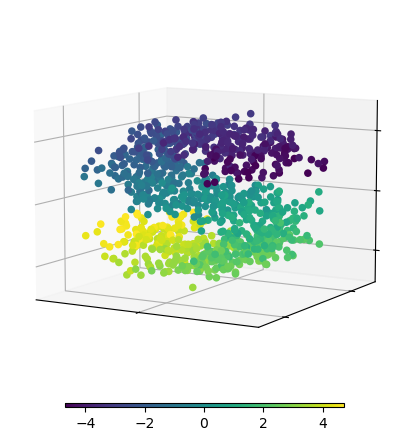

In [2]:
X_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_position_matrix.csv"))
V_gt = np.array(pd.read_csv("./data/s_curve/uniform/s_curve_gt_velocity_matrix.csv"))
t = pd.read_csv("./data/s_curve/uniform/s_curve_gt_latent_time_vector.csv")
t = list(t["t"])

plot_3d(
    X_gt,
    t,
    dot_size=30,
    alpha=1
)

In [3]:
seed=42
np.random.seed(seed)
sigma = 0.05                     # std-dev of the additive Gaussian noise
P = np.random.randn(3, 20) / np.sqrt(3)      # shape (3, 20)
X_20 = X_gt @ P            # (n, 20)
V_20 = V_gt @ P            # (n, 20)

# ----- 3.  add isotropic Gaussian noise ------------------------------------
X_noisy = X_20 + np.random.normal(loc=0.0, scale=sigma, size=X_20.shape)     # (n, 20)
V_noisy = V_20 + np.random.normal(loc=0.0, scale=sigma, size=V_20.shape)     # (n, 20)

/Users/jh/micromamba/envs/flowmap-manuscript/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running embedding with seed: 0
[PCA] Skipped (input dim = 20)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.
Running embedding with seed: 1
[PCA] Skipped (input dim = 20)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


...

[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.
Running embedding with seed: 5
[PCA] Skipped (input dim = 20)
[Init] Target embedding dimension: 2D
[Init] Computing phase distance graph …
[Init] Embedding with UMAP (precomputed) …


[TPS] Fitting geometry spline …


[TPS] Mapping vector field …
[TPS] Fitting vector-field spline …


[Init] Done.


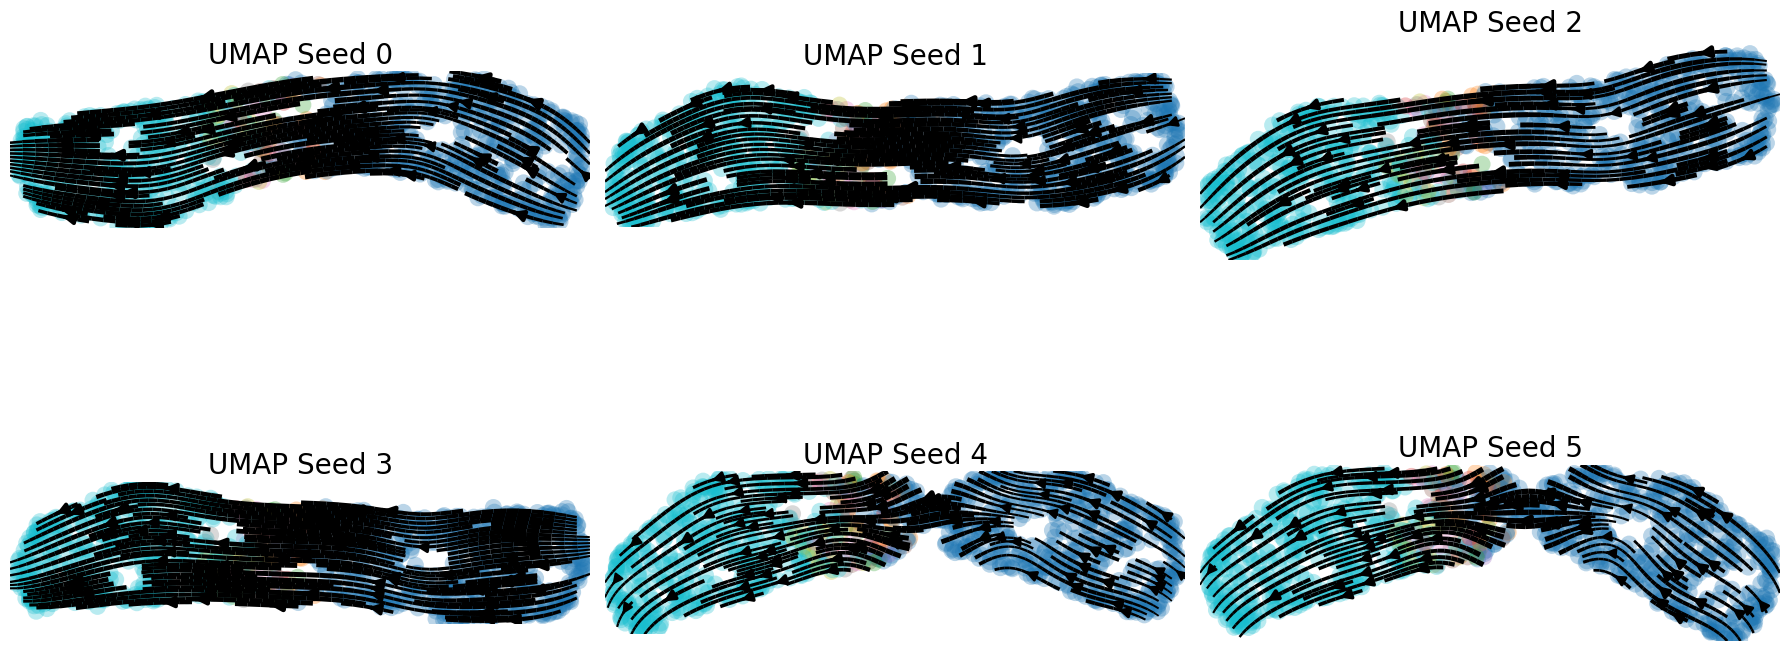

In [4]:
import numpy as np, random, os
from scripts.VectorFieldEmbedder import *

# handy helper to (optionally) pass an axis to your plotting function
def plot_on_axis(ax, emb, t):
    # If plot_velocity_streamplot supports an `ax` argument, pass it.
    # Otherwise let it create its own figure and copy artists to ax.
    try:
        plot_velocity_streamplot(
            X_2d=emb.X_emb,
            tps_vf=getattr(emb, 'tps_viz_vf', emb.tps_vf),
            scatter_color=t,
            grid_density=1.0,
            stream_density=1.5,
            scatter_size=150,
            scatter_alpha=0.3,
            aspect=1,
            vmin=0.0,
            vmax=1.0,
            grid_size=50,
            show_axes=False,
            ax=ax
        )
    except TypeError:
        # fallback: generate internally, then transfer image (quick hack)
        fig_tmp = plt.figure(figsize=(4, 3))
        plot_velocity_streamplot(
            X_2d=emb.X_emb,
            tps_vf=getattr(emb, 'tps_viz_vf', emb.tps_vf),
            scatter_color=t,
            grid_density=1.0,
            stream_density=1.5,
            scatter_size=150,
            scatter_alpha=0.3,
            aspect=1,
            vmin=0.0,
            vmax=1.0,
            grid_size=50,
            show_axes=False
        )
        # grab the artists from the tmp figure
        for artist in fig_tmp.axes[0].get_children():
            ax.add_artist(artist)
        plt.close(fig_tmp)

# -------------------------------------------------------------------
seeds = [0 + i for i in range(6)]        # six distinct seeds
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

embeddings = {}                  # <-- 1️⃣  dictionary to collect results

for ax, seed in zip(axes, seeds):
    print(f"Running embedding with seed: {seed}")

    # reproducibility
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # embed
    emb = VectorFieldEmbedder(
        X_noisy, V_noisy,
        dist_method="phase",
        use_PCA=False,
        dof=30,
        embed_kwargs={"n_neighbors": 30, "min_dist": 0.4},
    )
    emb.initialize_embedding(seed=seed)

    embeddings[seed] = emb       # <-- 2️⃣  save it

    # plot
    plot_on_axis(ax, emb, t)
    ax.set_title(f"UMAP Seed {seed}", fontsize=20)

# clean up unused axes (none in this case)
for ax in axes[len(seeds):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from matplotlib.gridspec import GridSpec

if not hasattr(next(iter(embeddings.values())), "fit_principal_curve"):
    print("Skipping twist/principal-curve panel: current VectorFieldEmbedder has no fit_principal_curve API.")
else:
    fig = plt.figure(figsize=(15, 10))
    outer = GridSpec(2, 3, wspace=0.25, hspace=0.3)

    for idx, seed in enumerate(sorted(embeddings)[:6]):
        emb = embeddings[seed]
        gs  = outer[idx].subgridspec(2, 1,
                                     height_ratios=[3, 1],
                                     hspace=0.05)
        ax_t = fig.add_subplot(gs[0])
        ax_b = fig.add_subplot(gs[1])
        plot_curve_and_twist(emb, seed, ax_t, ax_b, twist_vmin=0.0, twist_vmax=12.0)

    plt.tight_layout()
    plt.show()


Skipping twist/principal-curve panel: current VectorFieldEmbedder has no fit_principal_curve API.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

if not hasattr(next(iter(embeddings.values())), "fit_principal_curve"):
    print("Skipping unfold/twist correction panel: current VectorFieldEmbedder has no principal-curve API.")
else:
    # how many folds to flip for each seed 0...5
    peak_targets = [3, 2, 1, 0, 3, 0]

    rows, cols = 2, 3
    fig, axes  = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
    axes = axes.ravel()

    for ax, (seed, n_peaks) in zip(axes, zip(sorted(embeddings), peak_targets)):
        emb = embeddings[seed]

        # 1) principal curve + twist
        pc, twist = emb.fit_principal_curve(smooth=10)

        # 2) choose exactly n_peaks strongest folds
        peaks = emb.call_twist_peaks(
            twist, pc.pseudotimes,
            num_peaks=n_peaks, prom_mult=5.0
        )
        untwist_lams = pc.pseudotimes[peaks].tolist()

        # 3) unfold with those positions
        emb.unfold(pc=pc, untwist_lambdas=untwist_lams)

        # 4) plot velocity field on this subplot
        plot_velocity_streamplot(
            X_2d=emb.X_emb,
            tps_vf=getattr(emb, 'tps_viz_vf', emb.tps_vf),
            scatter_color=t,
            grid_density=1.0,
            stream_density=1.0,
            scatter_size=150,
            scatter_alpha=0.1,
            aspect=1,
            vmin=0.0, vmax=1.0,
            grid_size=50,
            show_axes=False,
            ax=ax
        )
        ax.set_title(f"Seed {seed}  |  flips: {n_peaks}", fontsize=11)

    for ax in axes[len(embeddings):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


Skipping unfold/twist correction panel: current VectorFieldEmbedder has no principal-curve API.
